# Fine-tuning HyenaDNA for chromatin accessibility prediction

Adapted from https://huggingface.co/LongSafari/hyenadna-small-32k-seqlen and https://colab.research.google.com/drive/1wyVEQd4R3HYLTUOXEEQmp_I8aNC_aLhL  
**Note: didn't work in torch 2.8.0, did work in torch 2.6.0.** Importing the model also requires omegaconf to be installed.

## Load packages

`utils_hyenadna.py` is a module that should be included with in directory. It depends on `utils_finetuning.py` and `standalone_hyenadna.py` (the latter of which is downloaded directly from the original repository).

In [2]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import anndata as ad
import torch
import crested
import lightning
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import transformers
from utils_hyenadna import HyenaDNATokenizerAnnDataModule, build_hyenadna_model, CharacterTokenizerv2, HyenaDNAScalarModel

In [2]:
torch.set_float32_matmul_precision('medium')

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CREsted version: {crested.__version__}")
print(f"Transformers version: {transformers.__version__}")

PyTorch version: 2.6.0+cu124
CREsted version: 1.5.0
Transformers version: 4.54.1


## Prepare data paths
Download the data for the notebooks from the dedicated Zenodo link of the CREsted paper, then use it below.  
This data can also be recreated with the data from `crested.get_dataset("mouse_cortex_bigwig_cut_sites")`, see next sections.

In [4]:
# Data paths
data_dir = Path("crested_data/Figure_5/") # CHANGE TO OWN LOCATION OF EXTRACTED crested_data.tar.gz
adata_file = data_dir / "data/mouse_biccn_data_full.h5ad" 
adata_filtered_file = data_dir / "data/mouse_biccn_data_specific.h5ad"
# Genome paths
resources_dir = Path("mm10_ucsc/fasta/") # CHANGE TO OWN
genome_file = resources_dir / "mm10.fa"
chromsizes_file = resources_dir / "mm10.chrom.sizes"

In [5]:
genome = crested.Genome(genome_file, chromsizes_file)
crested.register_genome(genome)

2025-08-28T11:02:51.480715+0200 INFO Genome mm10 registered.


## First round training

### Load data

In [6]:
if os.path.exists(adata_file):
    adata = ad.read_h5ad(adata_file)
    crested.pp.change_regions_width(
        adata,
        2048,
        chromsizes_file=chromsizes_file,
    )
else:
    print("Couldn't find anndata file - creating from scratch")
    atac_dir, regions_file = crested.get_dataset("mouse_cortex_bigwig_cut_sites")
    adata = crested.import_bigwigs(
        bigwigs_folder=atac_dir,
        regions_file=regions_file,
        target_region_width=1000, 
        target="count",
    )
    crested.pp.train_val_test_split(
        adata, strategy="chr", val_chroms=["chr8", "chr10"], test_chroms=["chr9", "chr18"]
    )
    crested.pp.change_regions_width(
        adata,
        2048,
        chromsizes_file=chromsizes_file,
    )
    crested.pp.normalize_peaks(
        adata, top_k_percent=0.03
    )  # The top_k_percent parameters can be tuned based on potential bias towards cell types. If some weights are overcompensating too much, consider increasing the top_k_percent. Default is 0.01


### Define model

In [7]:
tokenizer = CharacterTokenizerv2(
    characters=['A', 'C', 'G', 'T', 'N'],  # add DNA characters
    model_max_length = 32_000
)
base_model = build_hyenadna_model('hyenadna-small-32k-seqlen')

Loaded pretrained weights ok!


In [9]:
loss = crested.tl.losses.CosineMSELogLoss(max_weight=100, multiplier=1)
# metrics = {'mse': torchmetrics.MeanSquaredError().to('cuda'), 'pearson': torchmetrics.PearsonCorrCoef(adata.n_obs).to('cuda')}
model = HyenaDNAScalarModel(
    base_model, 
    loss = loss, 
    # lr = 5e-5, 
    lr = 1e-5,
    emb_shape = 256, 
    num_classes = adata.n_obs
).to('cuda')
model

HyenaDNAScalarModel(
  (base_model): HyenaDNAModel(
    (backbone): LMBackbone(
      (embeddings): GPT2Embeddings(
        (word_embeddings): Embedding(16, 256)
      )
      (layers): ModuleList(
        (0): Block(
          (mixer): HyenaOperator(
            (dropout): Dropout(p=0.0, inplace=False)
            (in_proj): Linear(in_features=256, out_features=768, bias=True)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
            (short_filter): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(2,), groups=768)
            (filter_fn): HyenaFilter(
              (dropout): Dropout(p=0.0, inplace=False)
              (pos_emb): PositionalEmbedding()
              (implicit_filter): Sequential(
                (0): Linear(in_features=5, out_features=64, bias=True)
                (1): Sin()
                (2): Linear(in_features=64, out_features=64, bias=True)
                (3): Sin()
                (4): Linear(in_features=64, out_features=6

### Data module
This data module is effectively a CREsted AnnDataModule, but with provisions to use HyenaDNA's tokenizer instead of one-hot encoding the data.

In [10]:
datamodule = HyenaDNATokenizerAnnDataModule(
    adata = adata,
    genome = genome,
    batch_size=32,  # lower this if you encounter OOM errors
    max_stochastic_shift=3,  
    always_reverse_complement=True,
    tokenizer = tokenizer,
    in_memory=True
)

In [11]:
datamodule.setup('fit')
datamodule.setup('test')

2025-08-27T11:36:21.920434+0200 INFO Loading sequences into memory...


100%|██████████| 440993/440993 [00:07<00:00, 59238.05it/s]


2025-08-27T11:36:30.075052+0200 INFO Loading sequences into memory...


100%|██████████| 56064/56064 [00:00<00:00, 91251.93it/s]


In [12]:
# Test whether the model works
sequence = 'ACTG' * (2048//4)
tok_seq = tokenizer(sequence, return_tensors='pt')["input_ids"].to('cuda')
model.model_pass(tok_seq).shape

torch.Size([1, 19])

### Training

In [13]:
# # setup the trainer
trainer = lightning.Trainer(
    default_root_dir = 'hyenadna', 
    logger = True, 
    max_epochs = 50,
    callbacks=[EarlyStopping(monitor = "val_loss", mode = "min"), ModelCheckpoint(monitor = "val_loss", mode = "min")]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [ ]:
# train the model
trainer.fit(model, datamodule.train_dataloader.data, datamodule.val_dataloader.data)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type          | Params | Mode 
-----------------------------------------------------
0 | base_model | HyenaDNAModel | 3.3 M  | train
1 | head       | Sequential    | 4.9 K  | train
-----------------------------------------------------
3.3 M     Trainable params
0         Non-trainable params
3.3 M     Total params
13.130    Total estimated model params size (MB)
110       Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Epoch 0:  86%|████████▌ | 23651/27563 [27:42<04:34, 14.23it/s, v_num=11]

## First round - check performance

In [3]:
# Load metrics of first training attempt with same lr as Borzoi/NucTrans
metrics = pd.read_csv('hyenadna/lightning_logs/version_5/metrics.csv')
display(metrics)
metrics_val = metrics[metrics['val_loss'].notna()]
display(metrics_val)


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,-0.339222,16.455870,0.375643,NaN,NaN,NaN
1,0,99,-0.279268,15.430815,0.328929,NaN,NaN,NaN
2,0,149,-0.368016,16.468576,0.440852,NaN,NaN,NaN
3,0,199,-0.401996,24.873182,0.568635,NaN,NaN,NaN
4,0,249,-0.402122,6.956316,0.155563,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
9383,16,468399,-0.638874,34.498478,0.859981,NaN,NaN,NaN
9384,16,468449,-0.555685,18.939285,0.821310,NaN,NaN,NaN
9385,16,468499,-0.472281,4.909923,0.606844,NaN,NaN,NaN
9386,16,468549,-0.392677,11.064462,0.331289,NaN,NaN,NaN


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
551,0,27562,NaN,NaN,NaN,-0.357298,65.256851,0.551956
1103,1,55125,NaN,NaN,NaN,-0.365395,63.346367,0.563468
1655,2,82688,NaN,NaN,NaN,-0.374014,62.198971,0.570776
2208,3,110251,NaN,NaN,NaN,-0.378570,61.041527,0.574633
2760,4,137814,NaN,NaN,NaN,-0.382838,59.847797,0.578718
3312,5,165377,NaN,NaN,NaN,-0.384607,59.385021,0.583546
3864,6,192940,NaN,NaN,NaN,-0.386861,58.947071,0.586273
4417,7,220503,NaN,NaN,NaN,-0.392749,58.298882,0.589406
4969,8,248066,NaN,NaN,NaN,-0.399071,57.506992,0.592485
5521,9,275629,NaN,NaN,NaN,-0.402539,56.776146,0.594032


In [4]:
# Load metrics of new training attempt with lower lr
metrics2 = pd.read_csv('hyenadna/lightning_logs/version_11/metrics.csv')
display(metrics2)
metrics2_val = metrics2[metrics2['val_loss'].notna()]
display(metrics2_val)


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,-0.254153,17.924799,0.405621,NaN,NaN,NaN
1,0,99,-0.261020,16.270107,0.323973,NaN,NaN,NaN
2,0,149,-0.265998,18.081228,0.448087,NaN,NaN,NaN
3,0,199,-0.344919,26.658474,0.571630,NaN,NaN,NaN
4,0,249,-0.428297,6.991649,0.153047,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
11623,21,580149,-0.624576,3.172425,0.604559,NaN,NaN,NaN
11624,21,580199,-0.559719,40.817188,0.729483,NaN,NaN,NaN
11625,21,580249,-0.569708,19.147018,0.494190,NaN,NaN,NaN
11626,21,580299,-0.682267,12.858909,0.654558,NaN,NaN,NaN


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
551,0,27562,NaN,NaN,NaN,-0.315894,77.704079,0.518111
1103,1,55125,NaN,NaN,NaN,-0.348746,69.511711,0.552800
1655,2,82688,NaN,NaN,NaN,-0.366072,65.072479,0.563350
2208,3,110251,NaN,NaN,NaN,-0.376351,62.460361,0.570445
2760,4,137814,NaN,NaN,NaN,-0.382288,61.170708,0.579750
3312,5,165377,NaN,NaN,NaN,-0.388710,60.070480,0.591091
3864,6,192940,NaN,NaN,NaN,-0.395422,58.997150,0.598178
4417,7,220503,NaN,NaN,NaN,-0.400752,58.263477,0.602949
4969,8,248066,NaN,NaN,NaN,-0.405236,57.409977,0.607349
5521,9,275629,NaN,NaN,NaN,-0.408984,56.549858,0.610358


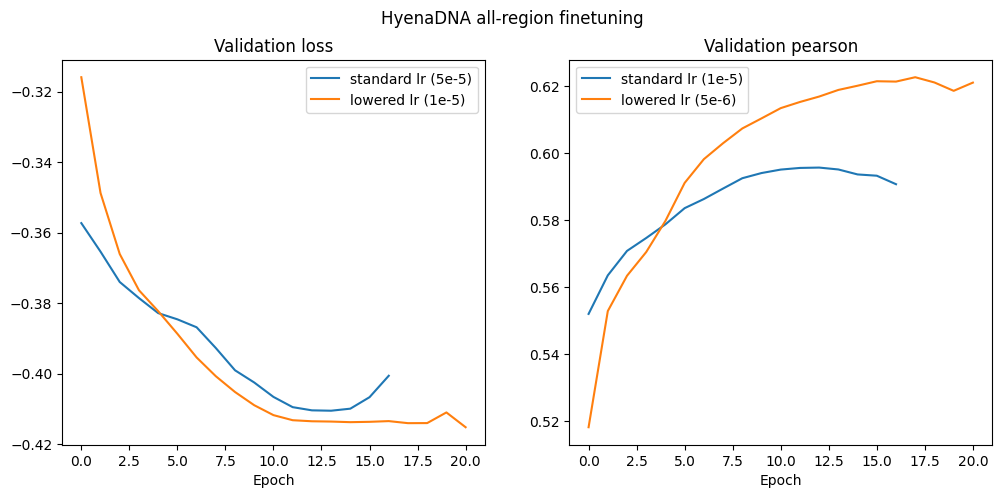

In [5]:
%matplotlib inline
fig, axs = plt.subplots(1, 2, figsize = (12, 5))
axs[0].plot(metrics_val['epoch'], metrics_val['val_loss'], label = 'standard lr (5e-5)')
axs[0].plot(metrics2_val['epoch'], metrics2_val['val_loss'], label = 'lowered lr (1e-5)')
axs[0].set_title('Validation loss')
axs[1].plot(metrics_val['epoch'], metrics_val['val_pearson'], label = 'standard lr (1e-5)')
axs[1].plot(metrics2_val['epoch'], metrics2_val['val_pearson'], label = 'lowered lr (5e-6)')
axs[1].set_title('Validation pearson')
axs[0].set_xlabel('Epoch')
axs[1].set_xlabel('Epoch')
axs[0].legend()
axs[1].legend()
fig.suptitle('HyenaDNA all-region finetuning')
plt.show()

## Second round


In [12]:
if os.path.exists(adata_filtered_file):
    adata = ad.read_h5ad(adata_filtered_file)
    crested.pp.change_regions_width(
        adata,
        2048,
        chromsizes_file=chromsizes_file,
    )
else:
    print("Couldn't find anndata file - creating from scratch")
    atac_dir, regions_file = crested.get_dataset("mouse_cortex_bigwig_cut_sites")
    adata = crested.import_bigwigs(
        bigwigs_folder=atac_dir,
        regions_file=regions_file,
        target_region_width=1000, 
        target="count",
    )
    crested.pp.train_val_test_split(
        adata, strategy="chr", val_chroms=["chr8", "chr10"], test_chroms=["chr9", "chr18"]
    )
    crested.pp.change_regions_width(
        adata,
        2048,
        chromsizes_file=chromsizes_file,
    )
    crested.pp.normalize_peaks(
        adata, top_k_percent=0.03
    )  # The top_k_percent parameters can be tuned based on potential bias towards cell types. If some weights are overcompensating too much, consider increasing the top_k_percent. Default is 0.01
    # This next part is same as running filtering on the previous adata, except for small seed/time of day/idk differences:
    crested.pp.filter_regions_on_specificity(
        adata, gini_std_threshold=1.0
    )

In [13]:
tokenizer = CharacterTokenizerv2(
    characters=['A', 'C', 'G', 'T', 'N'],  # add DNA characters
    model_max_length = 32_000
)
base_model = build_hyenadna_model('hyenadna-small-32k-seqlen')

Loaded pretrained weights ok!


In [17]:
# Only need base model here to provide the architecture, the weights will be overwritten by the checkpoint

loss = crested.tl.losses.CosineMSELogLoss(max_weight=100, multiplier=1)
model = HyenaDNAScalarModel.load_from_checkpoint(
    'hyenadna/lightning_logs/version_11/checkpoints/epoch=20-step=578823.ckpt', 
    base_model = base_model, 
    loss = loss, 
    lr = 5e-6
).to('cuda')
model

HyenaDNAScalarModel(
  (base_model): HyenaDNAModel(
    (backbone): LMBackbone(
      (embeddings): GPT2Embeddings(
        (word_embeddings): Embedding(16, 256)
      )
      (layers): ModuleList(
        (0): Block(
          (mixer): HyenaOperator(
            (dropout): Dropout(p=0.0, inplace=False)
            (in_proj): Linear(in_features=256, out_features=768, bias=True)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
            (short_filter): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(2,), groups=768)
            (filter_fn): HyenaFilter(
              (dropout): Dropout(p=0.0, inplace=False)
              (pos_emb): PositionalEmbedding()
              (implicit_filter): Sequential(
                (0): Linear(in_features=5, out_features=64, bias=True)
                (1): Sin()
                (2): Linear(in_features=64, out_features=64, bias=True)
                (3): Sin()
                (4): Linear(in_features=64, out_features=6

In [18]:
datamodule = HyenaDNATokenizerAnnDataModule(
    adata = adata,
    genome = genome,
    batch_size=32,  # lower this if you encounter OOM errors
    max_stochastic_shift=3,  
    always_reverse_complement=True,
    tokenizer = tokenizer,
    in_memory=True
)

In [19]:
datamodule.setup('fit')
datamodule.setup('test')

2025-08-28T11:15:15.977017+0200 INFO Loading sequences into memory...


100%|██████████| 73326/73326 [00:06<00:00, 11848.20it/s]

2025-08-28T11:15:22.269446+0200 INFO Loading sequences into memory...



100%|██████████| 9951/9951 [00:00<00:00, 24420.04it/s]


In [20]:
# Test whether the model works
sequence = 'ACTG' * (2048//4)
tok_seq = tokenizer(sequence, return_tensors='pt')["input_ids"].to('cuda')
model.model_pass(tok_seq).shape

torch.Size([1, 19])

### Training

In [21]:
# setup the trainer
trainer = lightning.Trainer(
    default_root_dir = 'hyenadna', 
    logger = True, 
    max_epochs = 50,
    callbacks=[EarlyStopping(monitor = "val_loss", mode = "min"), ModelCheckpoint(monitor = "val_loss", mode = "min")]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [22]:
# train the model
trainer.fit(model, datamodule.train_dataloader.data, datamodule.val_dataloader.data)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type          | Params | Mode 
-----------------------------------------------------
0 | base_model | HyenaDNAModel | 3.3 M  | train
1 | head       | Sequential    | 4.9 K  | train
-----------------------------------------------------
3.3 M     Trainable params
0         Non-trainable params
3.3 M     Total params
13.130    Total estimated model params size (MB)
110       Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


/lustre1/project/stg_00002/lcb/cblaauw/software/mambaforge/envs/crested_py311_pt251_test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 4583/4583 [05:19<00:00, 14.33it/s, v_num=12]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 4583/4583 [05:16<00:00, 14.47it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 4583/4583 [05:14<00:00, 14.58it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 4583/4583 [05:16<00:00, 14.48it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 4583/4583 [05:16<00:00, 14.50it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 4583/4583 [05:13<00:00, 14.60it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 4583/4583 [05:15<00:00, 14.55it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 4583/4583 [05:16<00:00, 14.47it/s, v_num=12]    
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 8: 100%|██████████| 4583/4583 

## Second round - check performance

In [6]:
# Load metrics of first training attempt with same lr as Borzoi/NucTrans
metrics = pd.read_csv('hyenadna/lightning_logs/version_10/metrics.csv')
display(metrics)
metrics_val = metrics[metrics['val_loss'].notna()]
display(metrics_val)


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,-0.239222,53.257332,0.680299,NaN,NaN,NaN
1,0,99,-0.386708,36.441940,0.595496,NaN,NaN,NaN
2,0,149,-0.333447,10.928324,0.407328,NaN,NaN,NaN
3,0,199,-0.384445,23.306227,0.453874,NaN,NaN,NaN
4,0,249,-0.480266,5.816252,0.530181,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
643,6,31899,-0.448681,29.573332,0.610477,NaN,NaN,NaN
644,6,31949,-0.315211,6.935559,0.407283,NaN,NaN,NaN
645,6,31999,-0.597972,4.221349,0.637404,NaN,NaN,NaN
646,6,32049,-0.597616,2.920889,0.566737,NaN,NaN,NaN


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
91,0,4582,NaN,NaN,NaN,-0.305276,25.744843,0.503870
184,1,9165,NaN,NaN,NaN,-0.309174,25.533228,0.507449
276,2,13748,NaN,NaN,NaN,-0.310588,25.421419,0.509230
369,3,18331,NaN,NaN,NaN,-0.311917,25.340353,0.510292
462,4,22914,NaN,NaN,NaN,-0.311617,25.291336,0.510636
554,5,27497,NaN,NaN,NaN,-0.311893,25.242516,0.510892
647,6,32080,NaN,NaN,NaN,-0.311564,25.209461,0.510997


In [7]:
# Load metrics of new training attempt with lower lr
metrics2 = pd.read_csv('hyenadna/lightning_logs/version_12/metrics.csv')
display(metrics2)
metrics2_val = metrics2[metrics2['val_loss'].notna()]
display(metrics2_val)


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
0,0,49,-0.327947,48.676323,0.725079,NaN,NaN,NaN
1,0,99,-0.487289,32.108654,0.607770,NaN,NaN,NaN
2,0,149,-0.344367,10.704859,0.453233,NaN,NaN,NaN
3,0,199,-0.438557,22.735676,0.456047,NaN,NaN,NaN
4,0,249,-0.494752,5.501697,0.555474,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
828,8,41049,-0.408489,66.509338,0.780222,NaN,NaN,NaN
829,8,41099,-0.516658,8.353362,0.681587,NaN,NaN,NaN
830,8,41149,-0.502779,3.655506,0.476223,NaN,NaN,NaN
831,8,41199,-0.180877,9.053425,0.328258,NaN,NaN,NaN


,epoch,step,train_loss,train_mse,train_pearson,val_loss,val_mse,val_pearson
91,0,4582,NaN,NaN,NaN,-0.365679,24.665932,0.551976
184,1,9165,NaN,NaN,NaN,-0.368386,24.450266,0.555011
276,2,13748,NaN,NaN,NaN,-0.369649,24.308277,0.556829
369,3,18331,NaN,NaN,NaN,-0.369954,24.210009,0.558017
462,4,22914,NaN,NaN,NaN,-0.369994,24.113201,0.558546
554,5,27497,NaN,NaN,NaN,-0.370257,24.015079,0.558851
647,6,32080,NaN,NaN,NaN,-0.369398,23.961939,0.558813
740,7,36663,NaN,NaN,NaN,-0.368503,23.902132,0.559092
832,8,41246,NaN,NaN,NaN,-0.368626,23.812178,0.558839


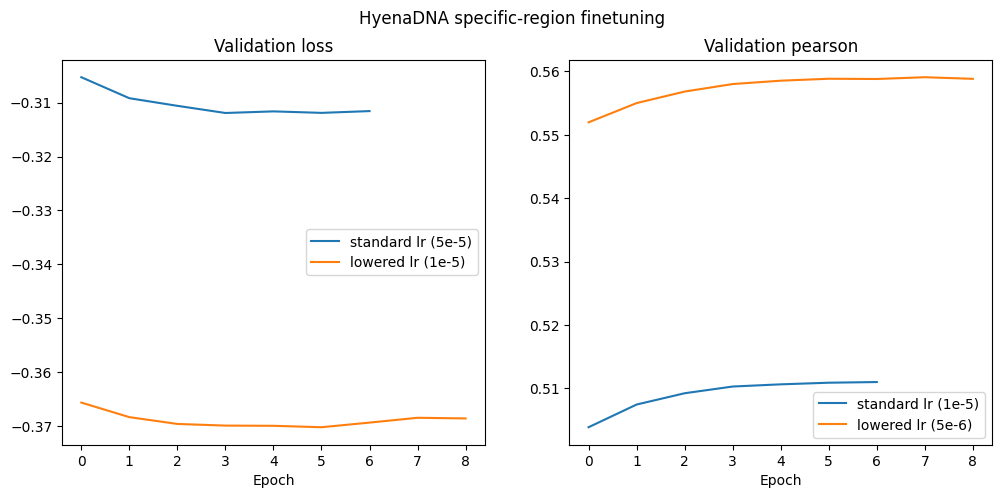

In [8]:
%matplotlib inline
fig, axs = plt.subplots(1, 2, figsize = (12, 5))
axs[0].plot(metrics_val['epoch'], metrics_val['val_loss'], label = 'standard lr (5e-5)')
axs[0].plot(metrics2_val['epoch'], metrics2_val['val_loss'], label = 'lowered lr (1e-5)')
axs[0].set_title('Validation loss')
axs[1].plot(metrics_val['epoch'], metrics_val['val_pearson'], label = 'standard lr (1e-5)')
axs[1].plot(metrics2_val['epoch'], metrics2_val['val_pearson'], label = 'lowered lr (5e-6)')
axs[1].set_title('Validation pearson')
axs[0].set_xlabel('Epoch')
axs[1].set_xlabel('Epoch')
axs[0].legend()
axs[1].legend()
fig.suptitle('HyenaDNA specific-region finetuning')
plt.show()